In [1]:
#Load Dataset
import struct
import numpy as np
import matplotlib.pyplot as plt


# ==========Load IDX Files ==========
def load_images(filename):
    with open(filename, 'rb') as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images=np.frombuffer(f.read(), dtype=np.uint8)
        images = images[:(len(images)//(rows * cols)) * rows * cols]
        return images.reshape(-1, rows * cols).astype(np.float32) / 255.0


def load_labels(filename):
    with open(filename, 'rb') as f:
        _, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels[:num]

In [2]:
# ========== 1. Sigmoid Function ==========
def sigmoid(z):
    # TODO: Implement sigmoid function
    z = np.clip(z, -500, 500)  # Prevent overflow
    return 1 / (1 + np.exp(-z))


# ====== 2. Mini Batch SGD: Algorithm 7.2 ======
def sgd_minibatch(X, y, eta=0.01, max_iters=10000, batch_size=64):
    N, d = X.shape
    w = np.zeros(d)
    n = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for _ in range(max_iters):
        if n + batch_size > N:
            np.random.shuffle(indices)
            n = 0
            
        batch_idx = indices[n:n+batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # Forward pass
        y_pred = sigmoid(np.dot(X_batch, w))
        
        # Calculate gradient for cross-entropy with sigmoid
        grad = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size
        
        # Weight vector update
        w = w - eta * grad
        n += batch_size

    return w


# ===== 3. Mini Batch SGD with Momentum: Algorithm 7.3 =====
def sgd_minibatch_momentum(X, y, eta=0.01, max_iters=10000, batch_size=64, momentum=0.9):
    N, d = X.shape
    w = np.zeros(d)
    dw = np.zeros(d)
    n = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for _ in range(max_iters):
        if n + batch_size > N:
            np.random.shuffle(indices)
            n = 0
            
        batch_idx = indices[n:n+batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # Forward pass
        y_pred = sigmoid(np.dot(X_batch, w))
        
        # Calculate gradient
        grad = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size
        
        # Calculate update term and weight vector update
        dw = -eta * grad + momentum * dw
        w = w + dw
        n += batch_size

    return w


# ====== 4. Adam Optimizer: Algorithm 7.4 ======
def sgd_Adam(X, y, eta=0.001, max_iters=10000, batch_size=64, beta1=0.9, beta2=0.999, delta=1e-8):
    N, d = X.shape
    w = np.zeros(d)
    s = np.zeros(d)
    r = np.zeros(d)
    n = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for t in range(1, max_iters + 1):
        if n + batch_size > N:
            np.random.shuffle(indices)
            n = 0
            
        batch_idx = indices[n:n+batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # Evaluate gradient vector
        y_pred = sigmoid(np.dot(X_batch, w))
        grad = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size

        # Update biased first moment estimate
        s = beta1 * s + (1 - beta1) * grad
        # Update biased second raw moment estimate
        r = beta2 * r + (1 - beta2) * (grad * grad)

        # Compute bias-corrected first moment estimate
        s_hat = s / (1 - beta1**t)
        # Compute bias-corrected second raw moment estimate
        r_hat = r / (1 - beta2**t)

        # Weight vector update
        w = w - eta * (s_hat / (np.sqrt(r_hat) + delta))
        n += batch_size

    return w

In [9]:
# ==========Show Misclassified Samples ==========
def show_misclassified(X, true_labels, pred_labels, max_show=10):
    mis_idx = np.where(true_labels != pred_labels)[0][:max_show]
    plt.figure(figsize=(10, 2.5))
    for i, idx in enumerate(mis_idx):
        plt.subplot(1, len(mis_idx), i + 1)
        plt.imshow(X[idx, 1:].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"T:{true_labels[idx]} P:{pred_labels[idx]}")
    plt.suptitle("Misclassified Samples")
    plt.show()

Test Accuracy (is 0 or not): 0.9929


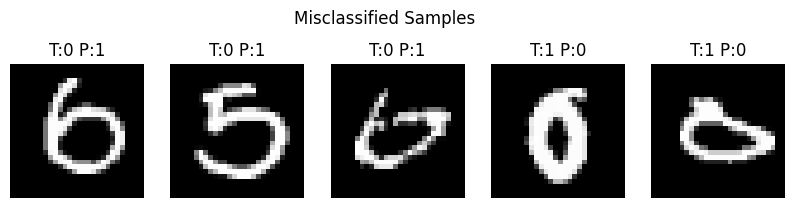

In [10]:
# ========== 3. Main ==========
if __name__ == "__main__":
    # === Load Data ===
    X_train = load_images("train-images.idx3-ubyte__")
    y_train = load_labels("train-labels.idx1-ubyte__")
    X_test = load_images("t10k-images.idx3-ubyte__")
    y_test = load_labels("t10k-labels.idx1-ubyte__")


    # === Choose binary classification target digit ===
    TARGET_DIGIT = 0   # TODO: Fill in (0 to 9)


    y_train_bin = np.where(y_train == TARGET_DIGIT, 1, 0)
    y_test_bin = np.where(y_test == TARGET_DIGIT, 1, 0)


    # === Add bias term ===
    X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])


    # === Set parameters ===
    max_iters = 5000
    batch_size = 64
    learning_rate = 0.001  # Adjust depending on the optimizer

    # === Train ===
    # w_final = sgd_minibatch(X_train, y_train_bin, eta=0.01, max_iters=max_iters, batch_size=batch_size)
    # w_final = sgd_minibatch_momentum(X_train, y_train_bin, eta=0.01, max_iters=max_iters, batch_size=batch_size, momentum=0.9)
    w_final = sgd_Adam(X_train, y_train_bin, eta=learning_rate, max_iters=max_iters, batch_size=batch_size)

    # === Predict ===
    y_test_pred_prob = sigmoid(np.dot(X_test, w_final))
    # Threshold at 0.5 for binary classification
    y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

    # === Evaluate ===
    accuracy = np.mean(y_test_pred == y_test_bin)
    print(f"Test Accuracy (is {TARGET_DIGIT} or not): {accuracy:.4f}")

    # === Show Misclassified Samples ===
    show_misclassified(X_test, y_test_bin, y_test_pred, max_show=5)